In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import cumulative_trapezoid
import scipy.constants as const
import astropy.constants as aconst
from pesummary.gw.conversions.mass import component_masses_from_mtotal_q
from simple_pe.waveforms import make_waveform, calculate_eccentric_harmonics

/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/lalsimulation/lalsimulation.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal
/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/pykerr/qnm.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this 

lal.MSUN_SI != Msun


In [3]:
params = {'mass_1': 40.814574636916944, 'mass_2': 30.759644668714774, 'chi_align': 0, 'ecc10': 0.06115}
h = make_waveform(params, 1/32, 20, int(4096*32)//2+1, 'TEOBResumS-Dali-Harms', n_ecc_harms=4)

2026-05-19  12:38:46 PESummary WARNING : Could not find f_final in input file and one was not passed from the command line. Using 1024.0Hz as default
2026-05-19  12:38:46 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default


input to harmonics with 0.06115, 10, 40.814574636916944, 30.75964466871477, default generation at 0.02957422825760719, 20
generating harmonics with 0.061150000000907534, 10.0, 40.814574636916944, 30.75964466871477


In [9]:
from simple_pe.cli.simple_pe_filter import calculate_eccentric_snr
from pycbc.psd import aLIGOZeroDetHighPower
psd = {'H1': aLIGOZeroDetHighPower(int(4096*32)//2+1, 1/32, 5)}
print(calculate_eccentric_snr(
    params, psd, 'TEOBResumS-Dali', {'H1': h[0]}, 20, -0.1, 0.1,
    return_ecc_harms=True, n_ecc_harms=3, n_ecc_gen=6
))

input to harmonics with 0.06115, 10, 40.814574636916944, 30.75964466871477, default generation at 0.02957422825760719, 20
generating harmonics with 0.04695274312115118, 12.878046424720758, 40.814574636916944, 30.75964466871477
({0: (0.9999205708446041+0j), 1: (-0.0002837342422387799-0.0001414027270802512j), -1: (-0.0009623405652290564+0.0013062656808393777j)}, {0: 1, 1: 0.4480404447104775, -1: 0.7787394520892185}, {0: <pycbc.types.frequencyseries.FrequencySeries object at 0x7fc2de24c730>, 1: <pycbc.types.frequencyseries.FrequencySeries object at 0x7fc2de24bac0>, -1: <pycbc.types.frequencyseries.FrequencySeries object at 0x7fc2de24c760>})


In [10]:
calculate_eccentric_harmonics(102.0167636490548, 1.0408163265306096, 0.09261182774496539, 0.004643609335838572, 0.004643609335838572, 20.0, 4096, 0.0, 0, 1.0, 10, 16, 3, 6, None, False, True, ['22'], 'TEOBResumS-Dali')

input to harmonics with 0.09261182774496539, 10, 52.02854946101788, 49.98821418803691, default generation at 0.04509334473460506, 20.0
generating harmonics with 0.1060605728486182, 8.753720504737117, 52.02854946101788, 49.98821418803691


{0: <pycbc.types.frequencyseries.FrequencySeries at 0x7fc2de24c520>,
 1: <pycbc.types.frequencyseries.FrequencySeries at 0x7fc2de24cd30>,
 -1: <pycbc.types.frequencyseries.FrequencySeries at 0x7fc2de24c7f0>}

In [9]:
f_low = 10
e = 0.5
m1 = 20*aconst.M_sun.value
m2 = 40*aconst.M_sun.value

In [5]:
t_orb = 2/(f_low)
a = (const.G*(m1+m2)*t_orb**2/(4*np.pi**2))**(1/3)
f_e = (1-e**2)/e**(12/19)*(1 + 121/304*e**2)**(-870/2299)
c0 = a*f_e
beta = 64/5*const.G**3*m1*m2*(m1+m2)/const.c**5
es = np.linspace(0, e, 500)
integrand = es**(29/19)*(1 + 121/304*es**2)**(1181/2299)/(1-es**2)**(3/2)
time = 12/19*c0**4/beta*np.trapz(integrand, es)
print(time/t_orb)

9.260411614445506


In [29]:
e_interps = np.linspace(0, 1, 10**6)[:-1]
f_e_interps = (1-e_interps**2)/e_interps**(12/19)*(1 + 121/304*e_interps**2)**(-870/2299)
print(f_e_interps[:10])

[          inf 6158.47822108 3975.11046764 3077.04374233
 2565.81295939 2228.53095179 1986.13819033 1801.88586879
 1656.15426185 1537.42496955]


/tmp/ipykernel_2342/1935117216.py:2: RuntimeWarning: divide by zero encountered in divide
  f_e_interps = (1-e_interps**2)/e_interps**(12/19)*(1 + 121/304*e_interps**2)**(-870/2299)


In [90]:
def calc_f_orbits(f_ref, e, m1, m2, x):

    # Calculate constants
    m1 *= aconst.M_sun.value
    m2 *= aconst.M_sun.value
    t_orb = 2/f_ref
    a = (const.G*(m1+m2)*t_orb**2/(4*np.pi**2))**(1/3)
    beta = 64/5*const.G**3*m1*m2*(m1+m2)/const.c**5
    e_min = 10**-10

    # Handle circular case
    if e < 100*e_min:
        f_start = (8*x*beta)**(-3/5)*(const.G*(m1+m2)/np.pi**2)**(4/5)
        return f_start
    else:
        f_e = (1-e**2)/e**(12/19)*(1 + 121/304*e**2)**(-870/2299)
        c_0 = a*f_e

    # Create interpolation function and interpolate
    e_interps = np.geomspace(e_min, 1, 10**6)[:-1]
    f_e_interps = ((1-e_interps**2)/e_interps**(12/19)*
                   (1 + 121/304*e_interps**2)**(-870/2299))
    t_orb_interps = np.sqrt(4*np.pi**2*(c_0/f_e_interps)**3/(const.G*(m1+m2)))
    f_interps = 2/t_orb_interps
    integrand = (e_interps**(29/19)*(1 + 121/304*e_interps**2)**(1181/2299)
                 /(1-e_interps**2)**(3/2))
    integrals = cumulative_trapezoid(integrand, e_interps, initial=0)
    t_interps = (12/19)*c_0**4/beta*integrals
    x_interps = t_interps/t_orb_interps
    plt.plot(f_interps, x_interps)
    plt.xlim(0, 50)
    plt.show()
    xf_interps = interp1d(x_interps, f_interps, bounds_error=False,
                          fill_value=f_interps[np.argmax(x_interps)])
    f_start = xf_interps(x)

    return f_start

In [49]:
np.geomspace(10**-10, 1, 10**6)[:-1]

array([1.00000000e-10, 1.00002303e-10, 1.00004605e-10, ...,
       9.99930925e-01, 9.99953949e-01, 9.99976974e-01])

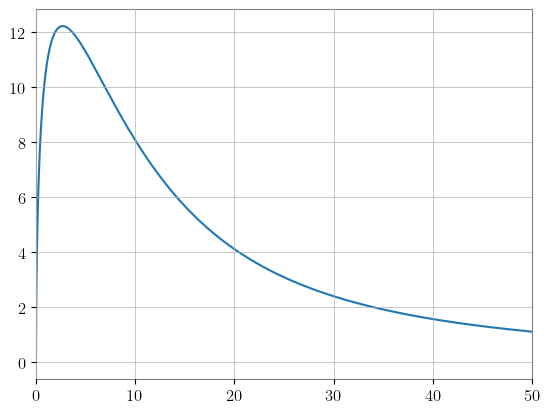

array(2.68982022)

In [91]:
calc_f_orbits(20, 0.264, 43, 42, 15)

In [232]:
x = 100
f_e = (1-e**2)/e**(12/19)*(1 + 121/304*e**2)**(-870/2299)
beta = 64/5*const.G**3*m1*m2*(m1+m2)/const.c**5
prefactor = (12/19)*(const.G*(m1+m2)/(4*np.pi**2))**(4/3)
es = np.linspace(0, e, 500)
integrand = es**(29/19)*(1 + 121/304*es**2)**(1181/2299)/(1-es**2)**(3/2)
integral = np.trapz(integrand, es)
f_low = 2*(prefactor*(1/x)*f_e**4/beta*integral)**(3/5)
print(f_low)

0.3137723052729844


In [2]:
params = {'total_mass': 2000, 'mass_ratio': 0.5, 'chi_align': 0, 'ecc10sqrd': 0.5**2}
hp, hc = make_waveform(params, 1/32, 8.7, int(32*4096)//2+1, 'TEOBResumS-Dali', return_hc=True)
hp_ts = hp.to_timeseries()
hc_ts = hc.to_timeseries()
plt.plot(hp_ts.sample_times, hp_ts)
plt.plot(hp_ts.sample_times, np.sqrt(hp_ts**2+hc_ts**2))
plt.plot(hp_ts.sample_times, -np.sqrt(hp_ts**2+hc_ts**2))
plt.xlim(-3,0.1)

2026-05-18  13:35:00 PESummary WARNING : Could not find f_final in input file and one was not passed from the command line. Using 1024.0Hz as default
2026-05-18  13:35:00 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default


0.5334669832931543 8.7 666.6666666666666 1333.3333333333333
3.635318197868111e-06


RuntimeError: initial conditions failed.